# 04 — Testes básicos de um ano EAC4 e mapas regionais

Este notebook usa **somente arquivos locais já consolidados**. Não inicia downloads
CAMS, não altera dados brutos e não modifica o manifesto. O ano padrão é **2003**,
conforme as datas mostradas no teste inicial. Os produtos são salvos em uma nova
pasta de execução em `reports/one_year/`.

Verifica os 12 meses, os seis poluentes, a grade, as unidades e os valores dos
campos processados. Complementa, mas não substitui, a validação dos originais por
`camsaq validate`. Um ano representa um ciclo mensal; não é uma climatologia de
longo prazo. Não são calculadas anomalias contra o próprio ano ou tendências.

In [1]:
from pathlib import Path
import os
import sys
import json
import hashlib
from datetime import datetime, timezone
from importlib.metadata import version

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

from cams_air_quality.config import load_config
from cams_air_quality.processing import open_database, product_root
from cams_air_quality.extraction import area_mean, subset_bbox, extract_point, save_table
from cams_air_quality.statistics import annual_mean, check_monthly
from cams_air_quality.maps import plot_map

# Modifique estas opções ou defina as variáveis de ambiente antes do nbconvert.
ANO = int(os.environ.get("CAMSAQ_YEAR", "2003"))
MES = int(os.environ.get("CAMSAQ_MONTH", "7"))
COSTAS = os.environ.get("CAMSAQ_COASTLINES", "0") == "1"
VARIAVEIS = ["pm25", "pm10", "co", "no2", "so2", "o3"]
REGIOES = {
    "brasil_bbox": [6, -75, -35, -30],
    "sudeste_bbox": [-14, -54, -26, -38],
    "europa_bbox": [72, -25, 34, 45],
}
if not 1 <= MES <= 12:
    raise ValueError("MES deve estar entre 1 e 12.")

config_env = os.environ.get("CAMSAQ_CONFIG")
if config_env:
    CONFIG = Path(config_env).expanduser().resolve()
else:
    CONFIG = next(
        (p / "config/config.yaml" for p in [Path.cwd(), *Path.cwd().parents]
         if (p / "config/config.yaml").is_file()),
        None,
    )
    if CONFIG is None:
        raise FileNotFoundError("Abra na pasta do projeto ou defina CAMSAQ_CONFIG.")
cfg = load_config(CONFIG)
ROOT = Path(cfg["root"])
if cfg.get("area") is not None:
    raise ValueError("Este teste requer a base GLOBAL (area: null).")
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = ROOT / "reports" / "one_year" / str(ANO) / RUN_ID
OUT.mkdir(parents=True, exist_ok=False)
print("Python:", sys.executable)
print("Configuração:", CONFIG)
print("Ano e mês:", ANO, MES)
print("Resultados:", OUT)

Python: /home/paulo/envs/cams/bin/python
Configuração: /home/paulo/Documentos/meus_codigos/cams/cams-global-air-quality/config/config.yaml
Ano e mês: 2003 7
Resultados: /home/paulo/Documentos/meus_codigos/cams/cams-global-air-quality/reports/one_year/2003/20260930T193048837357Z


## Abrir e selecionar exatamente um ano

A seleção temporal é lazy: não carrega outros anos na memória. O índice e os
metadados das partições são abertos pelo projeto. Se o índice estiver ausente,
processe e consolide os arquivos existentes antes de continuar. Não crie um
`index.json` vazio manualmente.

In [2]:
INDEX = product_root(cfg) / "index.json"
if not INDEX.is_file():
    raise FileNotFoundError(
        f"Índice ausente: {INDEX}. Execute camsaq process --kind monthly e "
        "camsaq consolidate --kind monthly; esses comandos não baixam dados."
    )
if "archive" in globals():
    archive.close()
archive = open_database(cfg)
ds = archive.sel(time=slice(f"{ANO}-01-01", f"{ANO}-12-31"))
expected = pd.date_range(f"{ANO}-01-01", periods=12, freq="MS")
actual = pd.DatetimeIndex(ds.time.values)
if not actual.equals(expected):
    raise ValueError(
        f"Esperados 12 meses ordenados de {ANO}. Ausentes: "
        f"{expected.difference(actual).strftime('%Y-%m').tolist()}; "
        f"datas encontradas: {actual.strftime('%Y-%m-%d').tolist()}"
    )
missing_vars = set(VARIAVEIS) - set(ds.data_vars)
if missing_vars:
    raise ValueError(f"Poluentes ausentes: {sorted(missing_vars)}")
check_monthly(ds.pm25)
np.testing.assert_allclose(ds.latitude.values, np.arange(90, -90.01, -0.75))
np.testing.assert_allclose(ds.longitude.values, np.arange(0, 360, 0.75))
for name in VARIAVEIS:
    if set(ds[name].dims) != {"time", "latitude", "longitude"}:
        raise ValueError(f"Dimensões inesperadas em {name}: {ds[name].dims}")
    expected_unit = cfg["registry"][name]["desired_units"]
    if ds[name].attrs.get("units") != expected_unit:
        raise ValueError(f"Unidade inesperada em {name}: {ds[name].attrs.get('units')}")
print("PASS: 12 meses, seis poluentes, grade global de 0,75° e unidades esperadas.")
print(ds[VARIAVEIS])

PASS: 12 meses, seis poluentes, grade global de 0,75° e unidades esperadas.
<xarray.Dataset> Size: 33MB
Dimensions:    (time: 12, latitude: 241, longitude: 480)
Coordinates:
  * latitude   (latitude) float64 2kB 90.0 89.25 88.5 ... -88.5 -89.25 -90.0
  * longitude  (longitude) float64 4kB 0.0 0.75 1.5 2.25 ... 357.8 358.5 359.2
  * time       (time) datetime64[ns] 96B 2003-01-01 2003-02-01 ... 2003-12-01
Data variables:
    pm25       (time, latitude, longitude) float32 6MB dask.array<chunksize=(1, 121, 120), meta=np.ndarray>
    pm10       (time, latitude, longitude) float32 6MB dask.array<chunksize=(1, 121, 120), meta=np.ndarray>
    co         (time, latitude, longitude) float32 6MB dask.array<chunksize=(1, 121, 120), meta=np.ndarray>
    no2        (time, latitude, longitude) float32 6MB dask.array<chunksize=(1, 121, 120), meta=np.ndarray>
    so2        (time, latitude, longitude) float32 6MB dask.array<chunksize=(1, 121, 120), meta=np.ndarray>
    o3         (time, latitude, long

## QC básico dos campos processados

As reduções são executadas por variável e mês. O teste exige campos finitos;
valores negativos são registrados como WARNING para investigação, sem truncá-los.
Um PASS numérico não demonstra acurácia observacional ou adequação epidemiológica.

In [3]:
qc_rows = []
for name in VARIAVEIS:
    for i, timestamp in enumerate(actual):
        field = ds[name].isel(time=i)
        metrics = xr.Dataset({
            "missing": field.isnull().sum(),
            "infinite": np.isinf(field).sum(),
            "minimum": field.min(skipna=True),
            "maximum": field.max(skipna=True),
        }).compute()
        missing = int(metrics["missing"].item())
        infinite = int(metrics["infinite"].item())
        minimum = float(metrics["minimum"].item())
        status = "FAIL" if missing or infinite else "WARNING" if minimum < 0 else "PASS"
        qc_rows.append({
            "pollutant": name,
            "month": timestamp.strftime("%Y-%m"),
            "units": field.attrs["units"],
            "missing_cells": missing,
            "infinite_cells": infinite,
            "minimum": minimum,
            "maximum": float(metrics["maximum"].item()),
            "status": status,
        })
qc = pd.DataFrame(qc_rows)
qc.to_csv(OUT / "qc_processed.csv", index=False)
display(qc.groupby(["pollutant", "status"]).size().rename("fields").reset_index())
if (qc.status == "FAIL").any():
    raise ValueError(f"QC reprovado. Consulte {OUT / 'qc_processed.csv'}")
print(f"QC concluído: {len(qc)} campos mensais. Avisos: {(qc.status == 'WARNING').sum()}.")

,pollutant,status,fields
0,co,PASS,12
1,no2,PASS,12
2,o3,PASS,12
3,pm10,PASS,12
4,pm25,PASS,12
5,so2,PASS,12


QC concluído: 72 campos mensais. Avisos: 0.


## Séries globais e médias anuais

A média espacial usa pesos de área da grade, não pesos populacionais. As médias
anuais são ponderadas pelo número de dias de cada mês. Os gases permanecem em
kg/kg. Cada gráfico contém um poluente para não misturar unidades ou escalas.

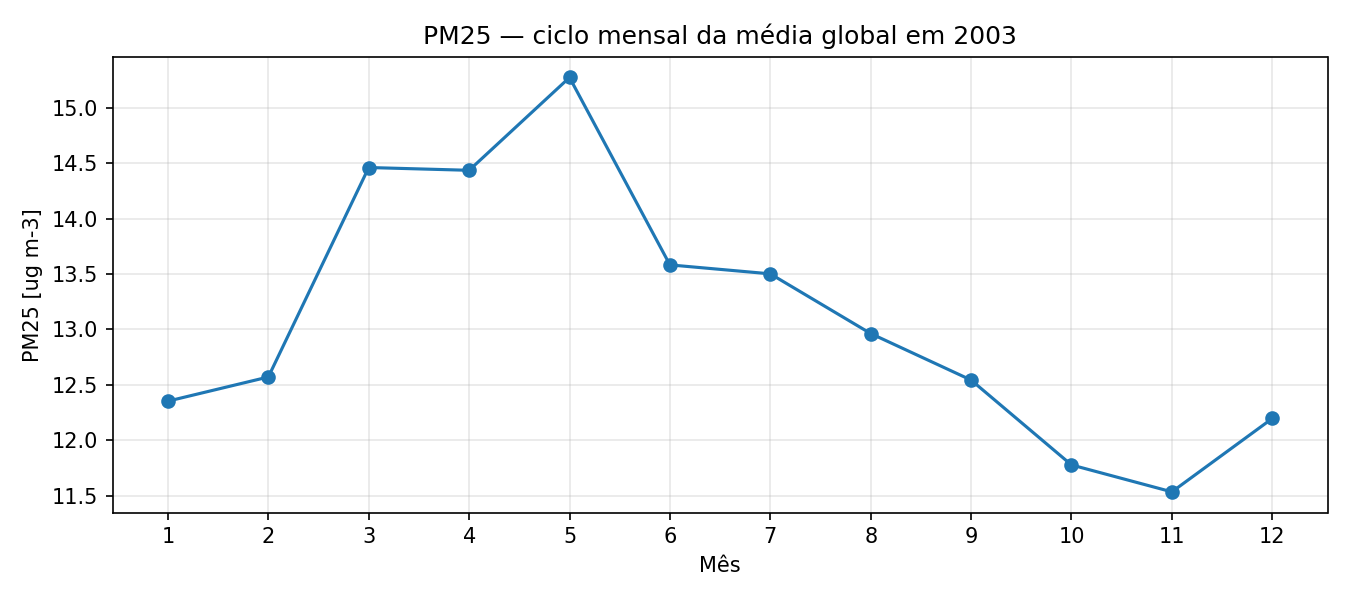

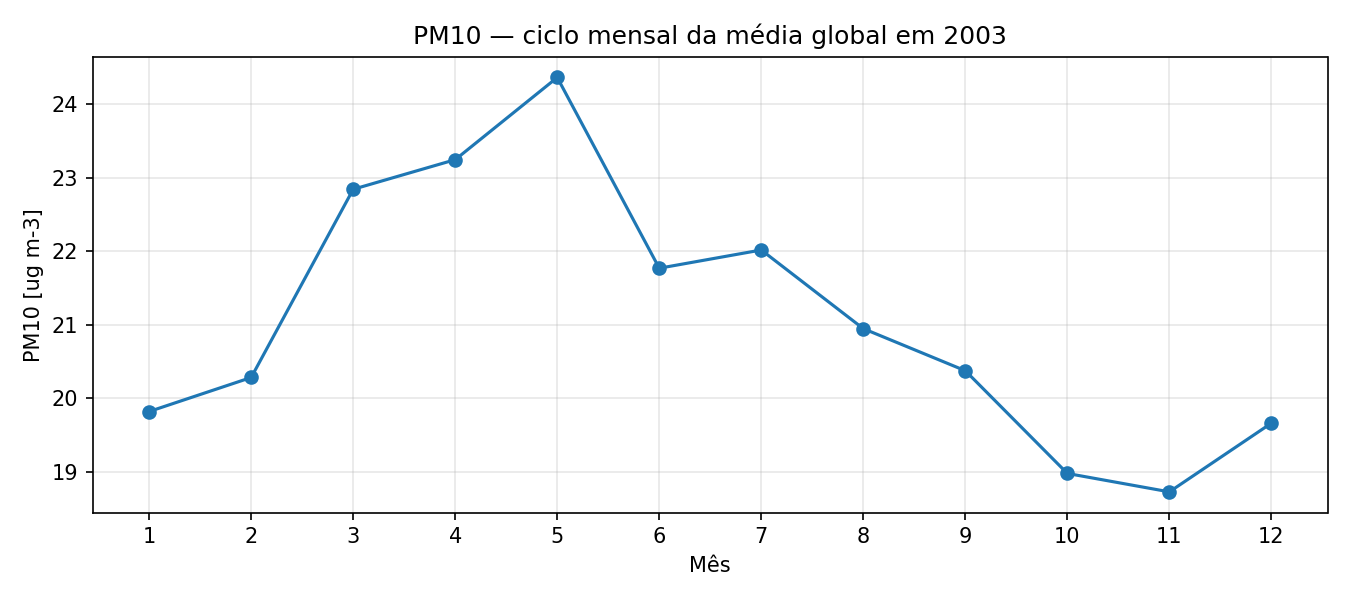

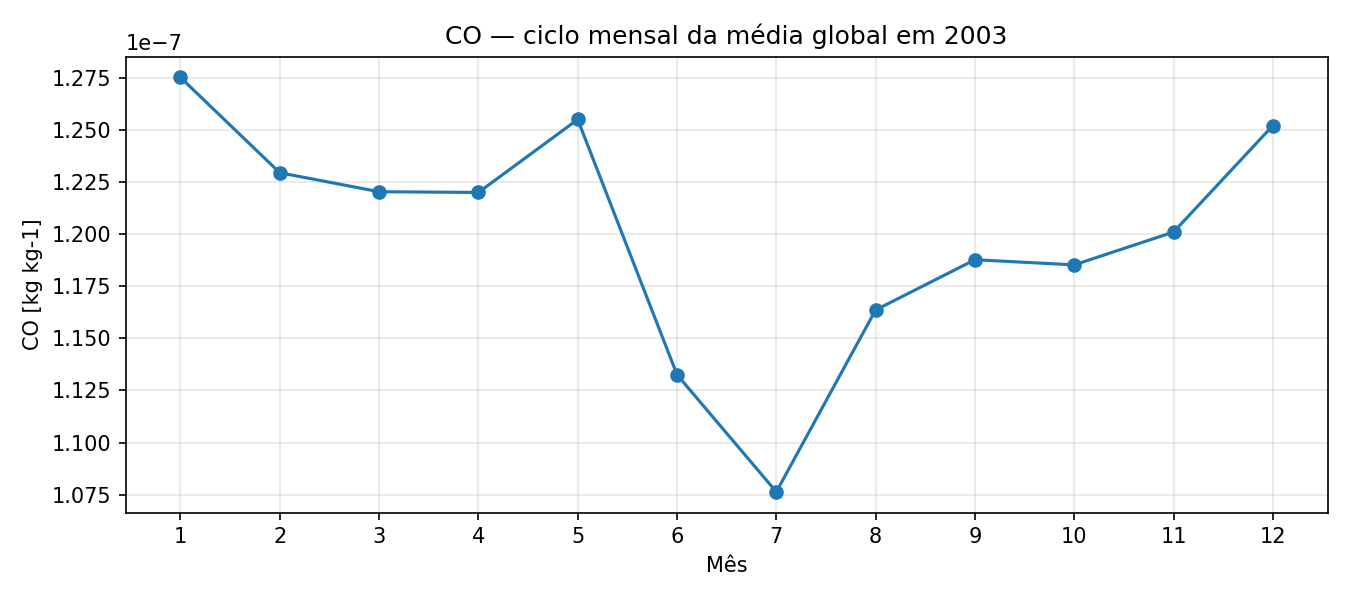

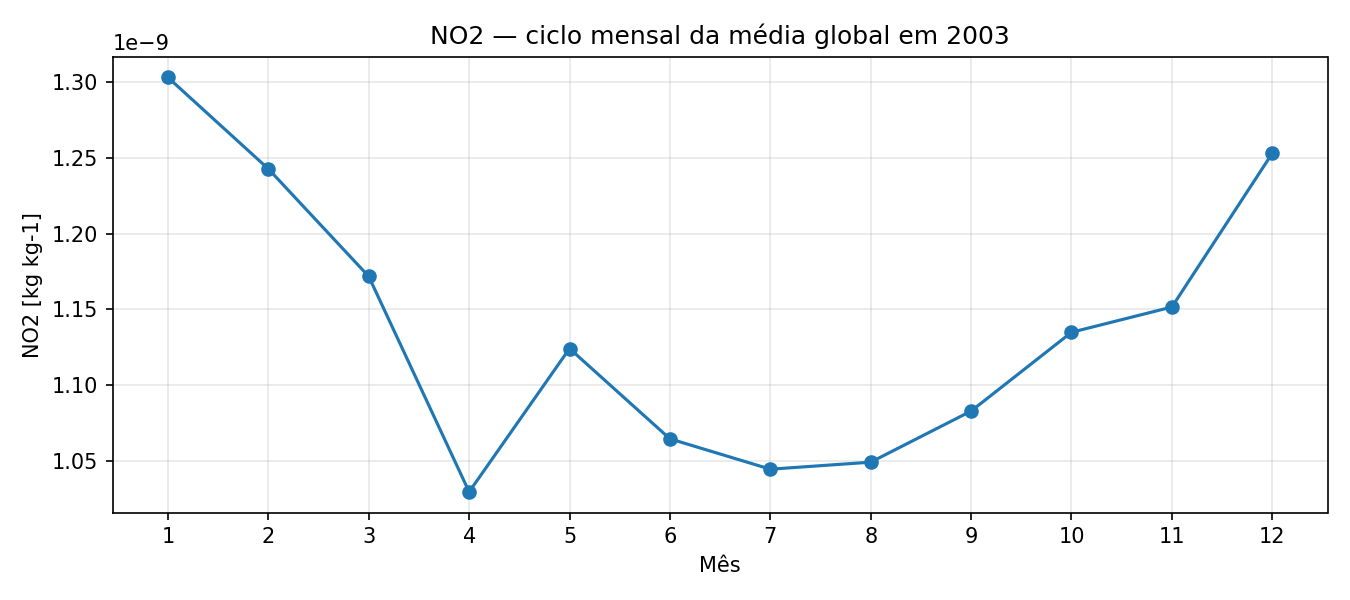

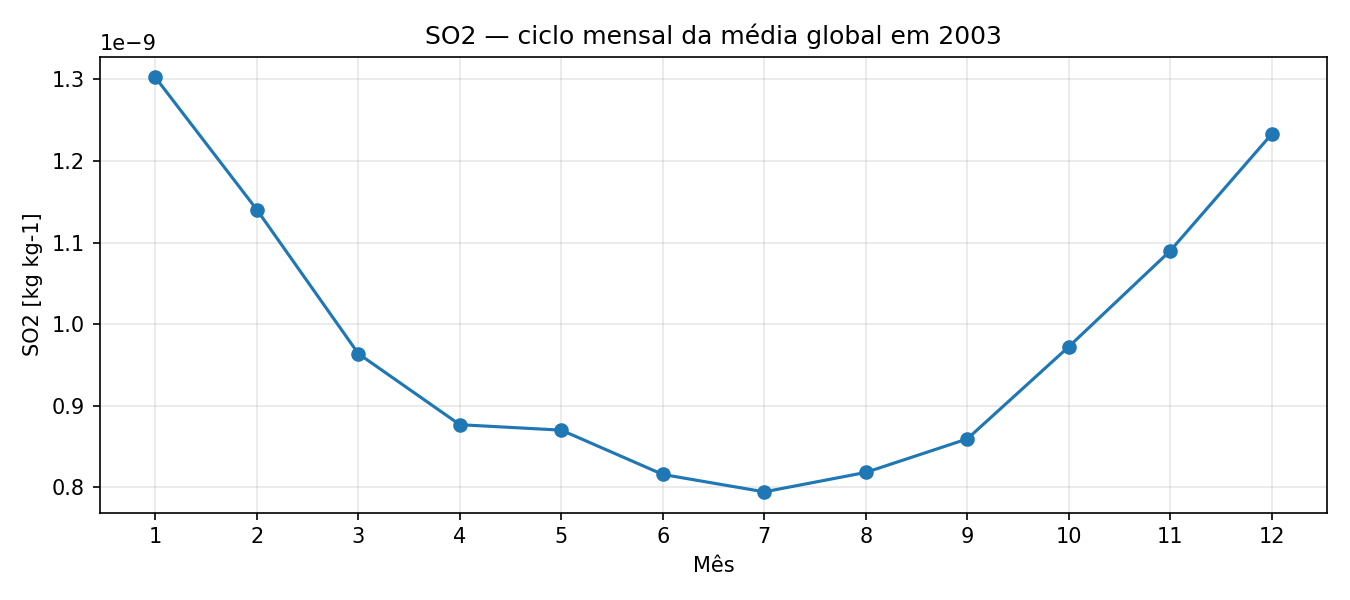

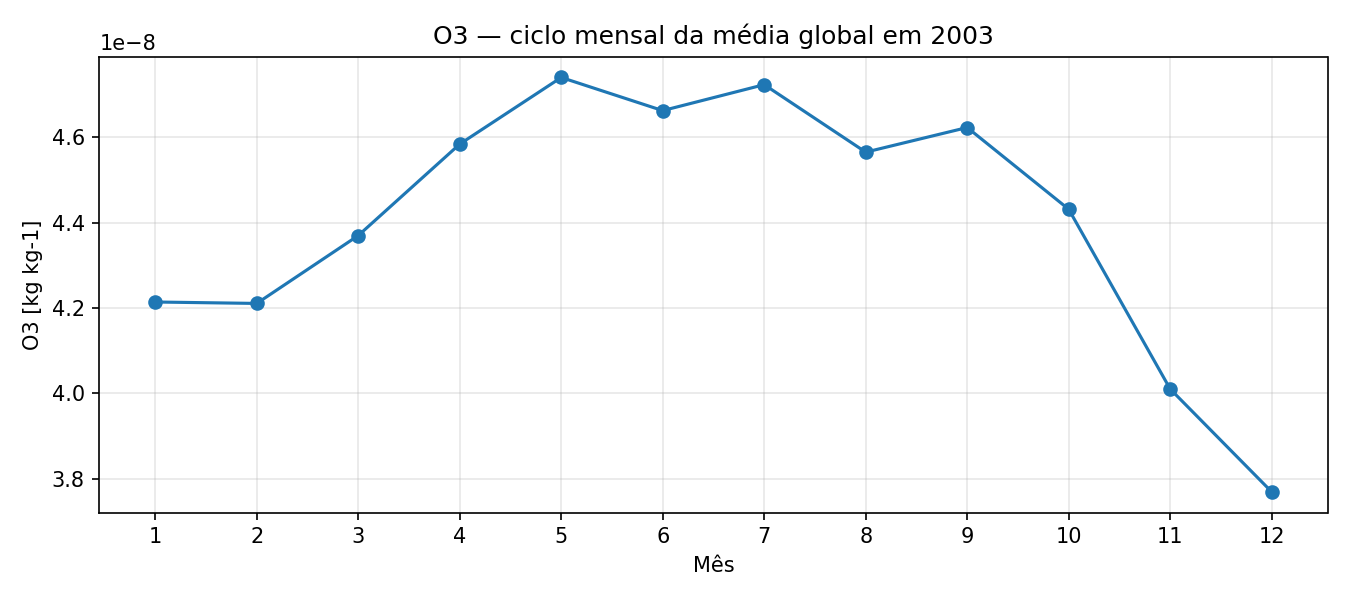

,pollutant,year,mean,units
0,pm25,2003,1.310432e+01,ug m-3
1,pm10,2003,2.109339e+01,ug m-3
2,co,2003,1.199722e-07,kg kg-1
3,no2,2003,1.137455e-09,kg kg-1
4,so2,2003,9.774897e-10,kg kg-1
5,o3,2003,4.409678e-08,kg kg-1


In [4]:
provenance = {
    "source": "EAC4",
    "year": ANO,
    "map_month": MES,
    "config_path": str(CONFIG),
    "source_index": str(INDEX),
    "source_index_sha256": hashlib.sha256(INDEX.read_bytes()).hexdigest(),
    "spatial_aggregation": "spherical cell-area weighted; not population weighted",
    "note": "one-year monthly cycle; not a long-term climatology",
}
annual_rows = []
for name in VARIAVEIS:
    series = area_mean(ds[name]).compute()
    frame = series.to_dataframe(name=name).reset_index()
    frame.attrs = {**provenance, "units": series.attrs["units"]}
    save_table(frame, OUT / f"{name}_global_monthly.csv")
    yearly = annual_mean(series)
    if yearly.sizes["time"] != 1:
        raise ValueError(f"Média anual incompleta para {name}")
    annual_rows.append({"pollutant": name, "year": ANO,
                        "mean": float(yearly.item()), "units": series.attrs["units"]})
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(series.time.dt.month.values, series.values, marker="o")
    ax.set(title=f"{name.upper()} — ciclo mensal da média global em {ANO}",
           xlabel="Mês", ylabel=f"{name.upper()} [{series.attrs['units']}]")
    ax.set_xticks(range(1, 13))
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    target = OUT / f"{name}_global_monthly.png"
    fig.savefig(target, dpi=150)
    plt.close(fig)
    display(Image(filename=str(target)))
annual_table = pd.DataFrame(annual_rows)
annual_table.attrs = {**provenance, "temporal_aggregation": "calendar-day weighted annual mean"}
save_table(annual_table, OUT / "global_annual.csv")
display(annual_table)

## Mapas globais e regionais de PM2.5

`REGIOES` usa a ordem **[norte, oeste, sul, leste]**. São recortes retangulares por
centros de células: o bbox do Brasil inclui partes de outros países e do oceano.
Não é uma máscara de fronteiras. Não há interpolação para uma grade mais fina.

`COSTAS=False` evita downloads externos no teste. Com `True`, o Cartopy pode
baixar os contornos Natural Earth na primeira utilização. A escala de cores é
automática por mapa; não compare apenas as cores entre mapas com limites diferentes.
O renderizador atual requer pelo menos dois centros em cada direção e um recorte
contínuo que não atravesse o antimeridiano.

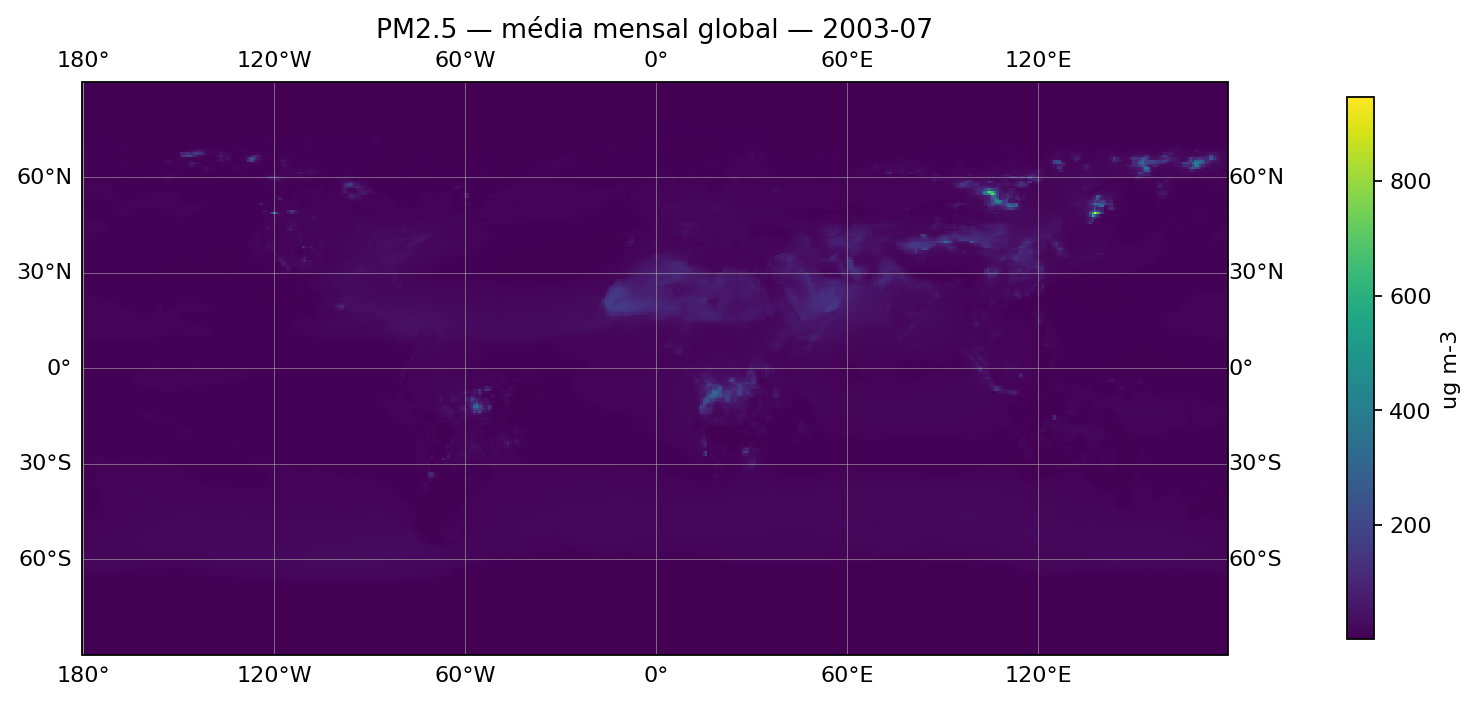

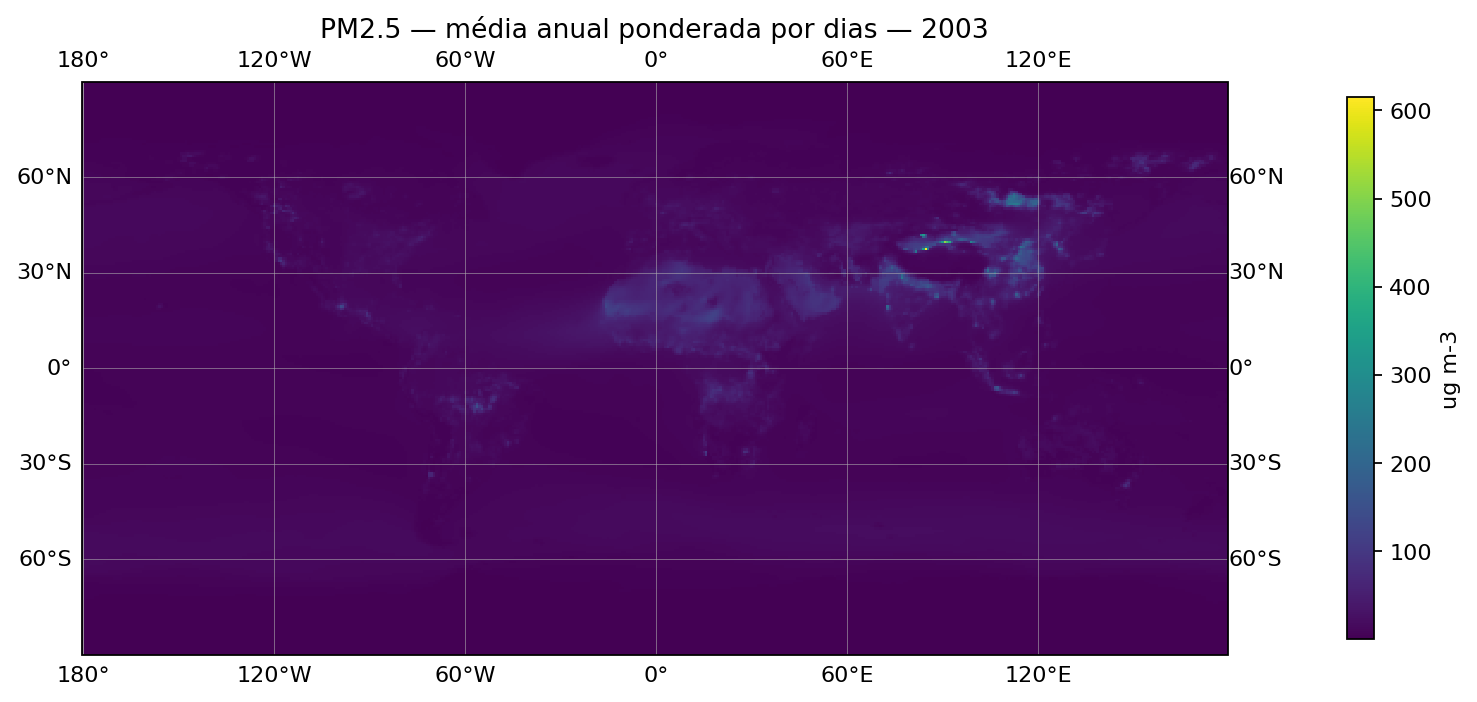

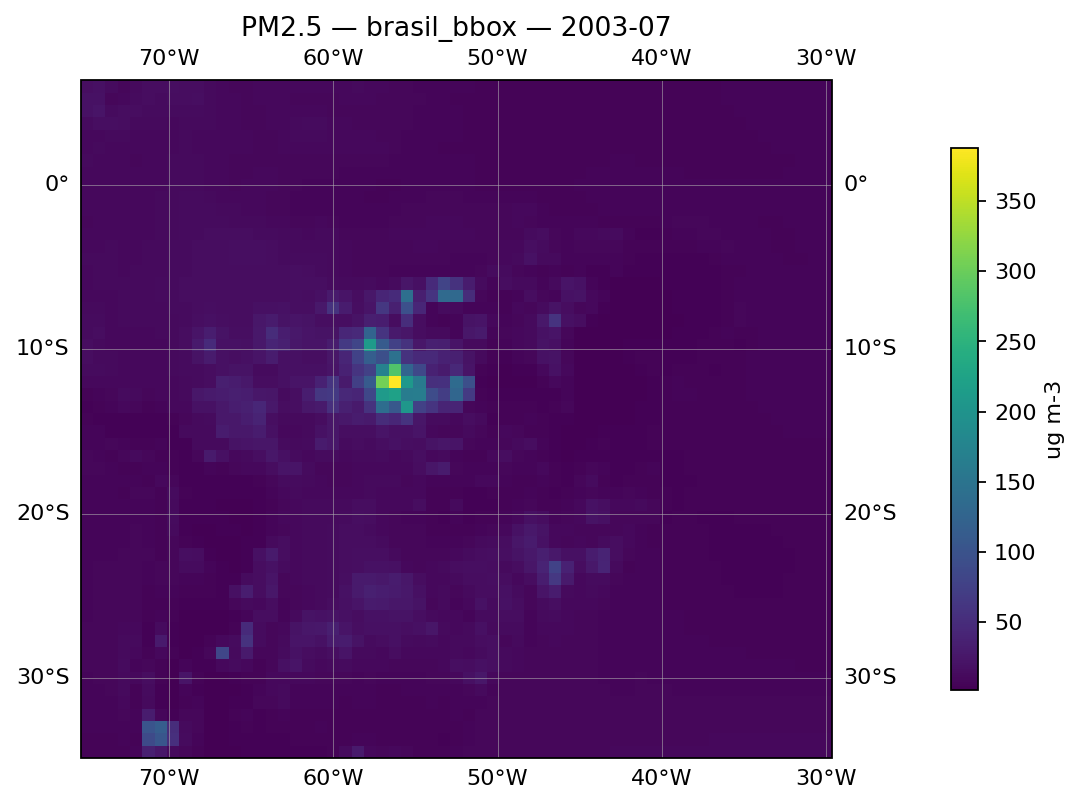

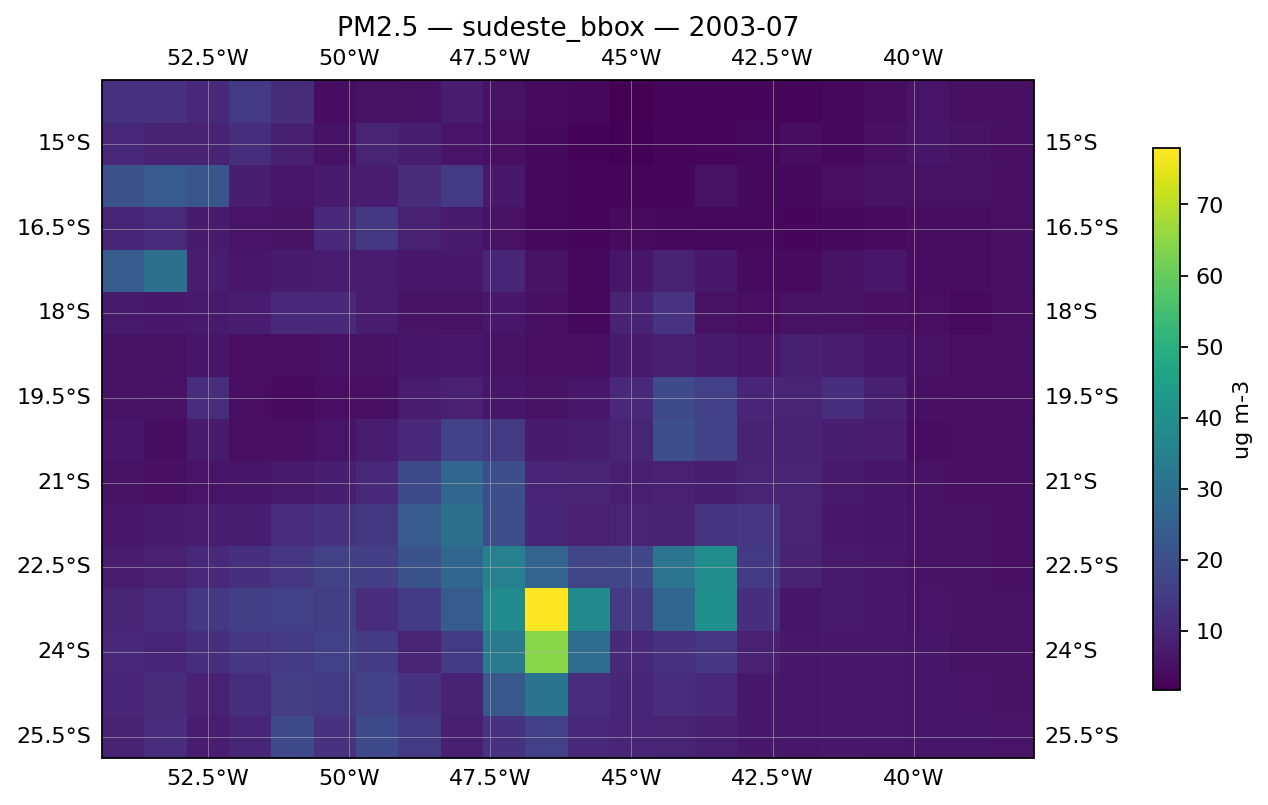

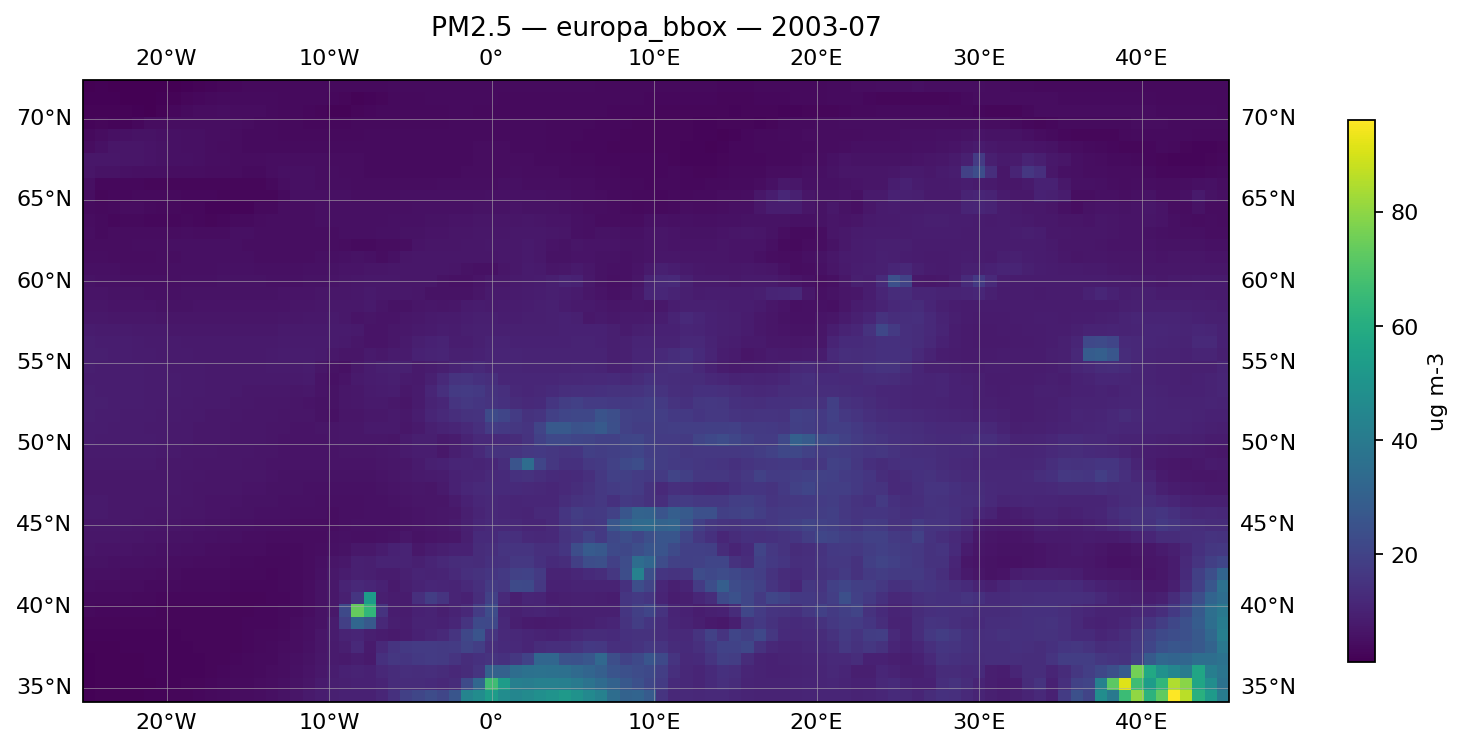

In [5]:
month_date = f"{ANO}-{MES:02d}-01"
field = ds.pm25.sel(time=month_date, drop=True)
map_paths = []
map_paths.append(plot_map(
    field, OUT / f"pm25_global_{ANO}_{MES:02d}.png",
    title=f"PM2.5 — média mensal global — {ANO}-{MES:02d}", coastlines=COSTAS,
))
annual_field = annual_mean(ds.pm25).isel(time=0, drop=True)
map_paths.append(plot_map(
    annual_field, OUT / f"pm25_global_annual_{ANO}.png",
    title=f"PM2.5 — média anual ponderada por dias — {ANO}", coastlines=COSTAS,
))
for region_name, bbox in REGIOES.items():
    regional = subset_bbox(field, *bbox)
    map_paths.append(plot_map(
        regional, OUT / f"pm25_{region_name}_{ANO}_{MES:02d}.png",
        title=f"PM2.5 — {region_name} — {ANO}-{MES:02d}", coastlines=COSTAS,
    ))
for target in map_paths:
    display(Image(filename=str(target)))

## São Paulo e séries regionais

A coordenada solicitada é um exemplo, não uma estação. A célula escolhida e sua
distância aproximada são registradas. Médias regionais abrangem os centros de
células contidos no bbox, inclusive oceano e áreas externas ao país/estado.

In [6]:
point = extract_point(ds[VARIAVEIS], lat=-23.5505, lon=-46.6333)
point_frame = point.to_dataframe().reset_index()
point_frame.attrs = {
    **point.attrs, **provenance,
    "units": {name: ds[name].attrs["units"] for name in VARIAVEIS},
}
save_table(point_frame, OUT / "sao_paulo_nearest_cell.csv")
save_table(point_frame, OUT / "sao_paulo_nearest_cell.parquet")
display(point_frame)
print("Célula selecionada:", point.attrs["selected_latitude"], point.attrs["selected_longitude"])
print("Distância aproximada (km):", point.attrs["distance_km_approx"])
for region_name, bbox in REGIOES.items():
    region_series = area_mean(subset_bbox(ds.pm25, *bbox)).compute()
    frame = region_series.to_dataframe(name="pm25").reset_index()
    frame.attrs = {**provenance, "bbox": bbox, "units": ds.pm25.attrs["units"]}
    save_table(frame, OUT / f"pm25_{region_name}_monthly.csv")

,time,pm25,pm10,co,no2,so2,o3,latitude,longitude
0,2003-01-01,39.961689,55.476959,2.876825e-07,1.254947e-08,1.479276e-08,2.574961e-08,-23.25,313.5
1,2003-02-01,51.366573,71.236305,3.449616e-07,1.534111e-08,1.851303e-08,3.651002e-08,-23.25,313.5
2,2003-03-01,45.036602,62.879833,2.854006e-07,1.376708e-08,1.852226e-08,2.965039e-08,-23.25,313.5
3,2003-04-01,67.257507,93.538628,4.285803e-07,1.682588e-08,2.696239e-08,2.660098e-08,-23.25,313.5
4,2003-05-01,73.076752,101.659172,4.606983e-07,1.730953e-08,3.207344e-08,2.541549e-08,-23.25,313.5
5,2003-06-01,85.333244,118.643883,5.735354e-07,2.013974e-08,3.788801e-08,2.869113e-08,-23.25,313.5
6,2003-07-01,77.940758,108.503624,5.133228e-07,1.922336e-08,4.071188e-08,3.135840e-08,-23.25,313.5
7,2003-08-01,67.998894,94.704361,4.496159e-07,1.924552e-08,2.843192e-08,3.328421e-08,-23.25,313.5
8,2003-09-01,58.036388,80.747910,4.037922e-07,1.606682e-08,2.093675e-08,4.390025e-08,-23.25,313.5
9,2003-10-01,46.528408,64.766014,3.348315e-07,1.494172e-08,1.794686e-08,4.234619e-08,-23.25,313.5


Célula selecionada: -23.25 313.5
Distância aproximada (km): 36.076954466121634


## Relatório e encerramento

Os checks abaixo descrevem os produtos processados selecionados. O inventário e
os checksums dos originais continuam sendo responsabilidade do manifesto e da CLI.
A base deve ser fechada após concluir os cálculos. Para retomar células anteriores,
execute novamente a célula que abre o arquivo.

In [7]:
index_snapshot = json.loads(INDEX.read_text())
(OUT / "source_index.json").write_text(json.dumps(index_snapshot, indent=2), encoding="utf-8")
packages = ["cams-global-air-quality", "numpy", "pandas", "xarray", "dask", "zarr", "matplotlib", "cartopy"]
report = {
    **provenance,
    "status": "WARNING" if (qc.status == "WARNING").any() else "PASS",
    "months": actual.strftime("%Y-%m").tolist(),
    "pollutants": VARIAVEIS,
    "field_checks": len(qc),
    "grid_shape": [ds.sizes["latitude"], ds.sizes["longitude"]],
    "regions": REGIOES,
    "versions": {package: version(package) for package in packages},
    "output_directory": str(OUT),
    "scope": "processed-data basic checks; does not replace raw-payload QC",
}
(OUT / "run_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
archive.close()
print(json.dumps(report, indent=2))

{
  "source": "EAC4",
  "year": 2003,
  "map_month": 7,
  "config_path": "/home/paulo/Documentos/meus_codigos/cams/cams-global-air-quality/config/config.yaml",
  "source_index": "/home/paulo/Documentos/meus_codigos/cams/cams-global-air-quality/data/processed/eac4/monthly/zarr/bc8112f9875a/index.json",
  "source_index_sha256": "7e71bf33697e4daa8cdec3b48060401685b3161530e19903c2a18987576058a8",
  "spatial_aggregation": "spherical cell-area weighted; not population weighted",
  "note": "one-year monthly cycle; not a long-term climatology",
  "status": "PASS",
  "months": [
    "2003-01",
    "2003-02",
    "2003-03",
    "2003-04",
    "2003-05",
    "2003-06",
    "2003-07",
    "2003-08",
    "2003-09",
    "2003-10",
    "2003-11",
    "2003-12"
  ],
  "pollutants": [
    "pm25",
    "pm10",
    "co",
    "no2",
    "so2",
    "o3"
  ],
  "field_checks": 72,
  "grid_shape": [
    241,
    480
  ],
  "regions": {
    "brasil_bbox": [
      6,
      -75,
      -35,
      -30
    ],
    "